# Step 0:- Problem Understanding

# Step 0.1:- Bussiness Problem


- The hotel wants to predict booking cancellations in advance to reduce revenue loss.

# Step 0.2:-ML Problem Type

- "Since the target variable has two classes (0 and 1) , this is a ***Classification Problem***"

# Step 0.3:- Target Variable

- "The Target variable is ***is_canceled*** because it is the output that our model predicts."

In [287]:
target="is_canceled"

#Step 0.4 :- Success Metric

- "The success metric helps us evaluate and compare models. We initially choose Accuracy and later confirm it after checking class balance."

# Step 1:- Import Libraries

In [288]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2:- Data Collection
- "Data Collection means loading the dataset and understanding its basic structure before analysis."

# Step 2.1:- Load Dataset

In [289]:
df=pd.read_csv("/content/hotel_bookings.csv.zip")

# Step 2.2:- Shape

In [290]:
# Shape tells the number of rows and columns in the dataset.
df.shape
# 119390 :- Total bookings (rows)
# 32 :- Total features(Columns)
# The dataset contains 119,390 records and 32 features.

(119390, 32)

# Step 2.3 :- Info

In [291]:
# Info shows the structure of the dataset.
df.info()
# I used info() to understand the dataset structure, data types, and identify missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# Step 2.4 :- Describe

In [292]:
# Describe gives the Statistical summary of numerical columns
df.describe().T
# I used describe() to understand the distribution and summary statistics of numerical features.

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


# Step 2.5 :- First Look(head())

In [293]:
df.head()
# I used head() to verify that the dataset loaded correctly and to understand the columns

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Step 3:- Exploratory Data Analysis

# Step 3.1:- Data Types

In [294]:
df.dtypes.value_counts()

,count
int64,16
object,12
float64,4


- I checked data types to identify numerical and categorical columns because each type requires different preprocessing technique before training the model.

# Step 3.2:- Missing Values

In [295]:
df.isnull().sum().sort_values(ascending=False)


,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


-  I checked for missing values to identify incomplete data. This helps me decide later whether to fill or remove missing values during preprocessing.

# Step 3.3:- Duplicate Values

In [296]:
# Duplicate values are repeated rows in the dataset.
df.duplicated().sum()
# Why?
# Duplicate rows can bias the model.

np.int64(31994)

- " I checked duplicate values to identify repeated records that may affect model performance"

# Step 3.4:- Numerical Columns

In [297]:
# Numerical Columns contain numbers that can be used for mathematical calculations.
num_cols=df.select_dtypes(include=['int64','float64']).columns
num_cols


Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

- I seperated numerical columns because they require different preprocessing than categorical features.

# Step 3.5:- Categorical Columns
- Categorical columns contain label or categories

In [298]:
cat_cols=df.select_dtypes(include=['object']).columns
cat_cols
# Why?
# Machine Learning cannot understand text.

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

- Categorical columns require encoding before model training.

# Step 3.6:- Target Analysis
- Target Analysis helps us understand the target variable distribution

In [299]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


In [300]:
# Percentage
df['is_canceled'].value_counts(normalize=True)*100

,proportion
is_canceled,
0,62.958372
1,37.041628


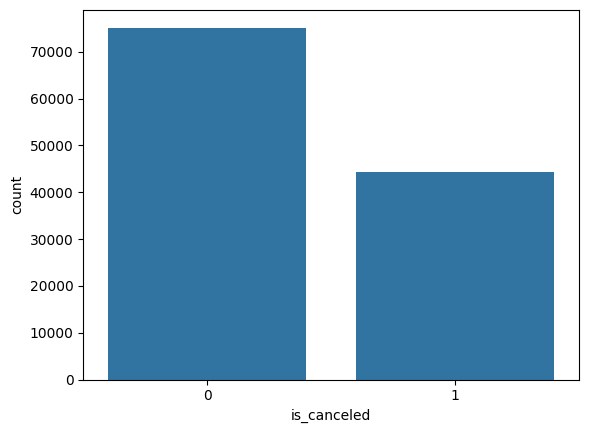

In [301]:
# Graph
sns.countplot(x='is_canceled',data=df)
plt.show()

In [302]:
# Why?
# To check whether the classes are balanced.

- "Target analysis helps identify whether the dataset is balanced or imbalanced"

# Step 3.7:- Univariate Analysis
- Univariate Analysis studies one variable at a time

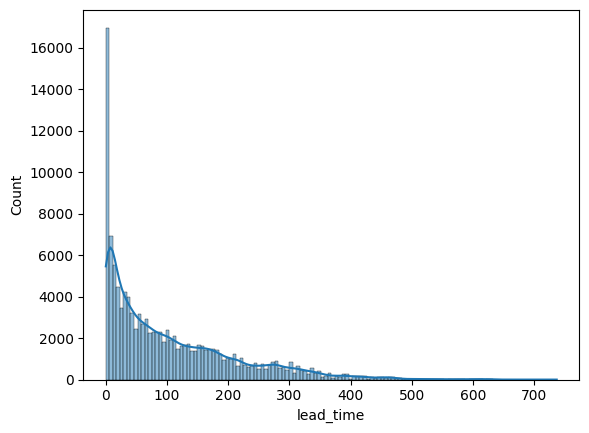

In [303]:
# Numerical
sns.histplot(df['lead_time'],kde=True)
plt.show()

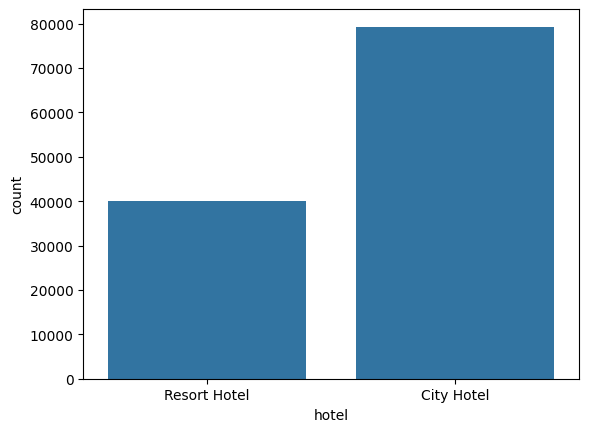

In [304]:
# Categorical
sns.countplot(x='hotel',data=df)
plt.show()

- "Univariate analysis helps understand the distribution of individual features."

# Step 3.8:- Bivariate Analysis
- Bivariate Analysis studies the relationship between two variables.

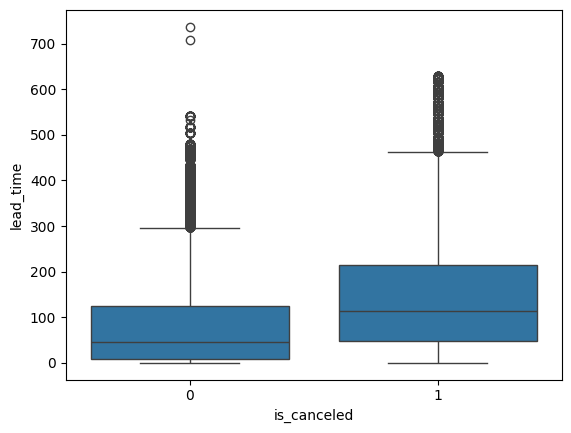

In [305]:
sns.boxplot(x='is_canceled',y='lead_time',data=df)
plt.show()

- or

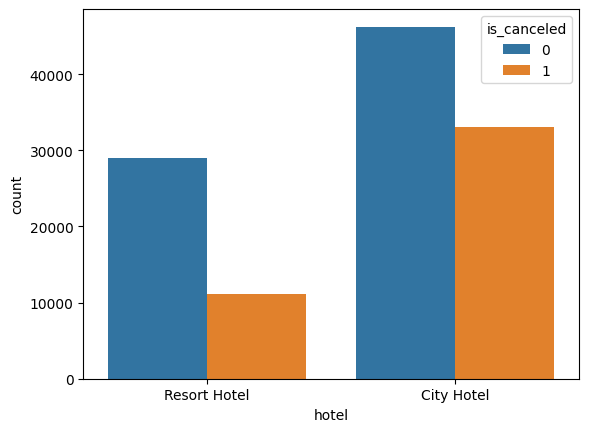

In [306]:
sns.countplot(x='hotel',hue='is_canceled',data=df)
plt.show()

- "Bivariate analysis helps understand the relationship between features and the target."

# Step 3.9:- Multivariate Analysis
- Multivariate Analysis studies three or more variables together.

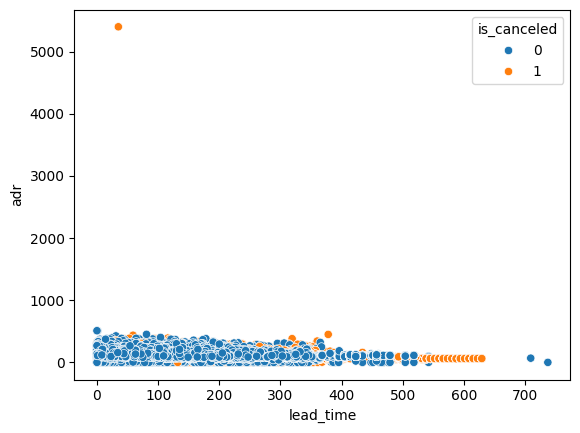

In [307]:
sns.scatterplot(
    x='lead_time',
    y='adr',
    hue='is_canceled',
    data=df
)

plt.show()

- "Multivariate analysis reveals relationships among multiple variables simultaneously."

# Step 3.10:- Correlation Analysis
- Correlation measures how strongly numerical variables are related.

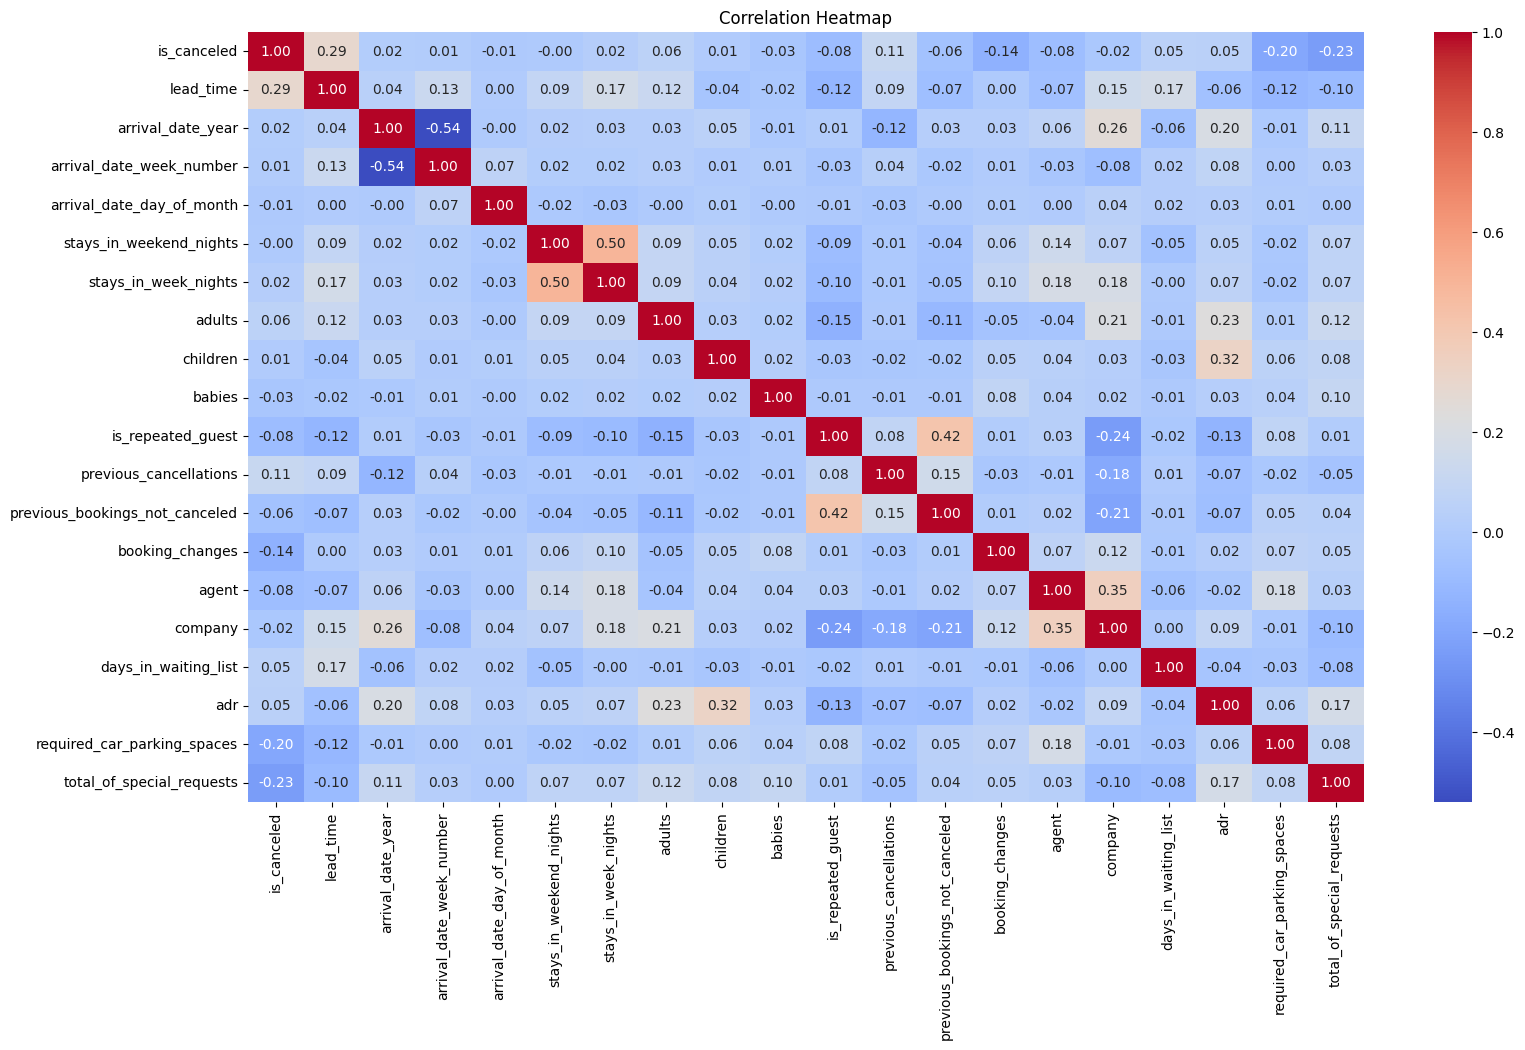

In [308]:
plt.figure(figsize=(18,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

- "Correlation helps identify positively and negatively related numerical features."

# Step 3.11:- Outliers Detection
- Outliers are unusually high or low values compared to the rest of the data.

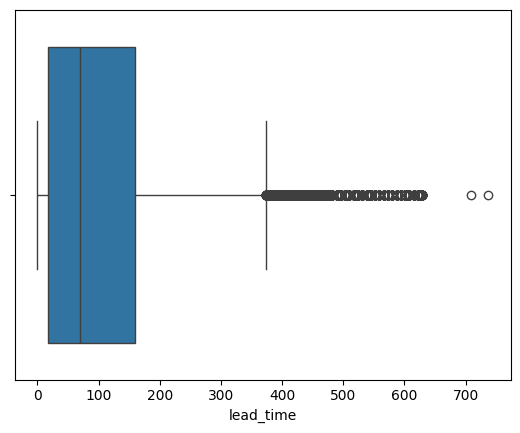

In [309]:
sns.boxplot(x=df['lead_time'])
plt.show()

- "Outlier detection helps identify extreme observations that may influence model performance."

# Step 3.12:- Business Insights
- Business Insights are meaningful conclusions drawn from EDA.

- "Business insights convert data analysis into actionable decisions for the business."

# Observation for step 3:-
- ***we only answer:-***
-   What is present?
-   What is wrong?
-   what patterns exist?
- we never clean, encode,scale or transform the data during EDA

# Step 4:- Feature Engineering

# Step 4.1:- Data Cleaning
- Data Cleaning is the process of identifying and correcting problems in the dataset to make it suitable for machine learning.

- ***Why do we do Data Cleaning?***

- Machine Learning models learn from the data we provide.

- If the data is dirty:-

- "Predictions become poor."
- "Accuracy decreases."
- "The model may even fail."

- "Data Cleaning is the process of identifying and correcting issues such as missing values, duplicates, incorrect data types, and inconsistent data to improve data quality before model training."

# Step 4.2 – Handle Missing Values
- Handling Missing Values means filling or removing empty (NaN) values before training the model.

In [310]:
df.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


# Step 4.3 – Remove Duplicate Values
- Duplicate Values are repeated rows in the dataset. Removing them helps avoid giving the same information multiple times to the model.

In [311]:
# Check Duplicate Values
df.duplicated().sum()

np.int64(31994)

In [312]:
#Remove Duplicate Values
df = df.drop_duplicates().copy()

In [313]:
# Verify
df.duplicated().sum()

np.int64(0)

- "I checked for duplicate records and removed them because duplicate data can bias the machine learning model and negatively affect performance."

# Step 4.4 – Fix Data Types
- Fix Data Types means converting columns into their correct data type for proper analysis and model training.

In [314]:
# Check Data Types
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [315]:
# Converting Object to Datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['reservation_status_date'].dtype

dtype('<M8[ns]')

# "How did you know this column should be converted?"
- "During EDA, I checked the data types and noticed that ***reservation_status_date*** was stored as an object. Since it contained date values, I converted it to datetime for proper date operations and future feature engineering."

# Step 4.5 – Feature Creation
- Feature Creation means creating new useful features (columns) from existing features to improve model performance.

In [316]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [317]:
# Check
df[['stays_in_weekend_nights',
    'stays_in_week_nights',
    'total_stay']].head()

,stays_in_weekend_nights,stays_in_week_nights,total_stay
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


# Why?

- Sometimes existing columns don't provide enough information.

- **Creating a new feature can:**

- "Improve prediction."
- "Reduce complexity."
- "Capture hidden patterns."

"Feature Creation involves generating new meaningful features from existing columns to improve the model's learning and predictive performance."

# Step 4.6 – Feature Transformation
- Feature Transformation means changing the format or values of a feature to make it more useful for machine learning.

In [318]:
# Convert month name into month number
month_map = {
    'January':1,'February':2,'March':3,
    'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,
    'October':10,'November':11,'December':12
}

df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

In [319]:
# check
df[['arrival_date_month']].head()

,arrival_date_month
0,7
1,7
2,7
3,7
4,7


# Why?

- Machine learning algorithms work better when features are in a suitable format.

- Transformation helps improve data quality without changing the actual meaning.

"Feature Transformation changes the format or representation of existing features without changing their meaning, making them more suitable for machine learning."

# Step 4.7:- Drop Irrelevant Columns
- Drop Irrelevant Columns means removing features that do not help the model learn or may cause data leakage.

In [320]:
df = df.drop(columns=[
    'company',
    'agent',
    'reservation_status',
    'reservation_status_date'
])

df.columns
# reservation_status:- they are same as target variable

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_stay'],
      dtype='object')

# Observation
- company has 94% missing values.
- It contributes very little useful information.
- Removing it simplifies the dataset.

"I removed irrelevant features because they provided little useful information and could negatively affect model performance."

# Step 5 – Feature & Target Separation
- Feature & Target Separation means dividing the dataset into input features (X) and the target variable (y).

In [321]:
# Deployment Friendly Features

X = df[[
    'hotel',
    'lead_time',
    'arrival_date_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'deposit_type',
    'customer_type',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'total_stay'
]]

y = df['is_canceled']

In [322]:
# Check Features
X.head()

,hotel,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_stay
0,Resort Hotel,342,7,0,0,2,0.0,0,BB,PRT,...,0,C,C,3,No Deposit,Transient,0.0,0,0,0
1,Resort Hotel,737,7,0,0,2,0.0,0,BB,PRT,...,0,C,C,4,No Deposit,Transient,0.0,0,0,0
2,Resort Hotel,7,7,0,1,1,0.0,0,BB,GBR,...,0,A,C,0,No Deposit,Transient,75.0,0,0,1
3,Resort Hotel,13,7,0,1,1,0.0,0,BB,GBR,...,0,A,A,0,No Deposit,Transient,75.0,0,0,1
4,Resort Hotel,14,7,0,2,2,0.0,0,BB,GBR,...,0,A,A,0,No Deposit,Transient,98.0,0,1,2


In [323]:
# Check Target
y.head()

,is_canceled
0,0
1,0
2,0
3,0
4,0


#Observation
- X contains all independent variables (features).
- y contains only the dependent variable (target).
- The model learns from X and predicts y.

"I separated the dataset into features (X) and the target variable (y). The model uses X as input to learn patterns and predicts the target variable y."

# Step 6 – Train-Test Split
- Train-Test Split is the process of dividing the dataset into training data and testing data.

In [324]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [325]:
# Checking the shapes.
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(69916, 24)
(17480, 24)
(69916,)
(17480,)


# Observation
- 80% of the data is used for training.
- 20% of the data is used for testing.
- random_state=42 gives the same split every time.
- stratify=y maintains the same class distribution in both train and test sets.

"I used Train-Test Split to train the model on one portion of the data and evaluate it on unseen data. This helps measure how well the model generalizes."

# Step 7 – Preprocessing
- Preprocessing is the process of preparing the training and testing data for machine learning by handling missing values, encoding categorical features, and scaling numerical features.

In [326]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

"Preprocessing prepares the data for machine learning by handling missing values, encoding categorical features, scaling numerical features, and combining all transformations using a pipeline."

# Step 7.1 – Identify Numerical & Categorical Columns
- Identify Numerical & Categorical Columns means separating the dataset into numeric and categorical features so each can receive the correct preprocessing.

In [327]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

cat_cols = X_train.select_dtypes(include=['object']).columns

In [328]:
print("Numerical Columns:")
print(num_cols)
print()

print("Categorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_stay'],
      dtype='object')

Categorical Columns:
Index(['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
       'reserved_room_type', 'assigned_room_type', 'deposit_type',
       'customer_type'],
      dtype='object')


"I separated numerical and categorical columns because each data type requires different preprocessing techniques. Numerical features are scaled, while categorical features are encoded."

# Step 7.2 – Missing Value Imputation
- Missing Value Imputation is the process of filling missing values using a suitable strategy before training the model.

In [329]:
# Numerical Imputer
num_imputer = SimpleImputer(strategy='median')

In [330]:
# Categorical Imputer
cat_imputer = SimpleImputer(strategy='most_frequent')

"I used SimpleImputer to handle missing values. I chose the median for numerical features because it is robust to outliers, and the most frequent value for categorical features because it preserves the existing category distribution."

# Step 7.3 – Encoding
- Encoding is the process of converting categorical (text) data into numerical data so that machine learning algorithms can understand it.

In [331]:
encoder = OneHotEncoder(handle_unknown='ignore')

"I used OneHotEncoder to convert categorical features into numerical format. I used handle_unknown='ignore' so that unseen categories during prediction do not cause errors."

#Step 7.4 – Scaling
- Scaling is the process of bringing numerical features to a similar range so that no feature dominates another during model training.

In [332]:
scaler = StandardScaler()

"I used StandardScaler to standardize numerical features so that all features have a similar scale, improving the performance of distance-based machine learning algorithms."

#Step 7.5 – Numerical Pipeline
- A Numerical Pipeline is a sequence of preprocessing steps applied only to numerical features.

In [333]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

"I created a numerical pipeline to combine median imputation and standard scaling into a single reusable preprocessing workflow for numerical features."

# Step 7.6 – Categorical Pipeline
- A Categorical Pipeline is a sequence of preprocessing steps applied only to categorical (text) features.

In [334]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

"I created a categorical pipeline that first fills missing categorical values using the most frequent category and then converts categorical features into numerical format using OneHotEncoder."

# Step 7.7 – ColumnTransformer
- ColumnTransformer applies different preprocessing pipelines to different types of columns in a single step.

In [335]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

"I used ColumnTransformer to apply different preprocessing pipelines to numerical and categorical features in a single, organized workflow."

# Step 7.8 –ML Pipeline
- The Final Preprocessing Pipeline combines the ColumnTransformer with the Machine Learning model into one complete workflow.

In [336]:
from sklearn.linear_model import LogisticRegression

ml_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

"I combined preprocessing and the machine learning model into a single pipeline. This ensures consistent preprocessing during training and prediction while preventing data leakage."

#Step 8 – Model Building
- Model Building is the process of training a machine learning algorithm using the training data to learn patterns and make predictions.


In [337]:
ml_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_ca...
       'total_stay'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
       'reserved_room_type', 'assigned_room_type', 'deposit_type',
       'customer_type'],
      dtype='object'))])),
                ('model', LogisticRegression())])

"During model building, I trained the machine learning algorithm using the training dataset so it could learn patterns and relationships between the input features and the target variable."

#Step 9 – Predictions
- Prediction is the process of using the trained model to predict the target values for unseen test data.

In [338]:
y_pred = ml_pipeline.predict(X_test)

In [339]:
# Check the predictions
y_pred[:5]

array([0, 0, 1, 0, 0])

"After training the model, I used the predict() method to generate predictions on the unseen test dataset. These predictions are later compared with the actual target values to evaluate model performance."

# Step 10 – Model Evaluation (Classification)
- Model Evaluation is the process of measuring how well the trained model performs on unseen data using evaluation metrics.

In [340]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [341]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7941075514874142


In [342]:
# Confusion Matrix
confusion_matrix(y_test, y_pred)

array([[11598,  1077],
       [ 2522,  2283]])

In [343]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87     12675
           1       0.68      0.48      0.56      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.70      0.71     17480
weighted avg       0.78      0.79      0.78     17480



• Accuracy: 79.4%

• The model predicts non-cancelled bookings very well.

• Recall for cancelled bookings is low (48%), meaning many cancellations are missed.

• This is likely due to class imbalance.

• Future improvements:
   - class_weight='balanced'
   - SMOTE
   - Random Forest
   - XGBoost

"I evaluated the model using Accuracy, Confusion Matrix, and Classification Report to understand its overall performance and class-wise prediction quality."

# Step 11 – Hyperparameter Tuning
- Hyperparameter Tuning is the process of finding the best parameter values for a machine learning algorithm to improve its performance.

In [344]:
from sklearn.model_selection import GridSearchCV

params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    ml_pipeline,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellation...
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
       'reserved_room_type', 'assigned_room_type', 'deposit_type',
       'customer_type'],
      dtype='object'))])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [345]:
# Best Parameters
print(grid.best_params_)

{'model__C': 10, 'model__solver': 'lbfgs'}


In [346]:
# Best Score
print(grid.best_score_)

0.7944390139644888


In [347]:
#Best Pipeline
best_pipeline = grid.best_estimator_

In [348]:
# Evaluate Tuned Model
y_pred = best_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7938787185354691


"I used GridSearchCV to find the best hyperparameter combination using cross-validation, which helped improve the model's performance."

# Step 12 – Save Model
- Saving a Model means storing the trained machine learning pipeline so it can be reused later without training again.

In [349]:
import joblib

# Save Best Model
joblib.dump(best_pipeline, 'hotel_booking_model.pkl')

# Load Model
model = joblib.load('hotel_booking_model.pkl')

"I used Joblib to save the trained machine learning pipeline so it can be loaded later for prediction without retraining the model."

In [350]:
# Verify Loaded Model
prediction = model.predict(X_test[:5])

print(prediction)

[0 0 1 0 0]


In [351]:
from google.colab import files

files.download("hotel_booking_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [352]:
best_pipeline.feature_names_in_

array(['hotel', 'lead_time', 'arrival_date_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
       'children', 'babies', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'reserved_room_type', 'assigned_room_type', 'booking_changes',
       'deposit_type', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_stay'], dtype=object)

In [353]:
print(best_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_ca...
       'total_stay'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
   